<div align="center">

# Load and Plot EEG Files

</div>

> This file serves the purpose of checking how to load and plot the EEG files

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

## 1. Simple function to load and plot

In [2]:
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        
    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]
    return signals, fs, ch_names, intervals

In [5]:
path = "../Data/chb07_19.h5"
signals, fs, ch_names, intervals = load_h5(path)

print(signals.shape)
print(fs)
print(ch_names)
print(intervals)

(18, 3689216)
256.0
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
[[3504128 3540736]]


In [6]:
signals

array([[-6.3020190e-07,  4.8128309e-06,  4.7611861e-06, ...,
        -1.1928381e-05, -5.5880914e-06, -5.5020422e-07],
       [-3.6281564e-09, -7.6308797e-06, -7.6839397e-06, ...,
        -4.0288955e-06,  4.8158887e-07,  1.4376976e-06],
       [-6.6779940e-08, -2.5213365e-06, -2.7545741e-06, ...,
        -2.1843785e-05, -1.4726408e-05, -1.8078099e-06],
       ...,
       [-2.4571011e-07, -1.5793845e-05, -1.6018348e-05, ...,
         9.5116711e-06,  4.1673402e-06,  6.2018995e-07],
       [-2.6097728e-08,  7.2372870e-08, -9.9624936e-07, ...,
        -1.0545166e-05, -2.3263021e-06,  1.1296919e-06],
       [-4.9573355e-08, -2.0791447e-05, -1.9633891e-05, ...,
         1.4998602e-05,  6.2590270e-06,  3.0950584e-06]], dtype=float32)

# 2. EEG with all channels

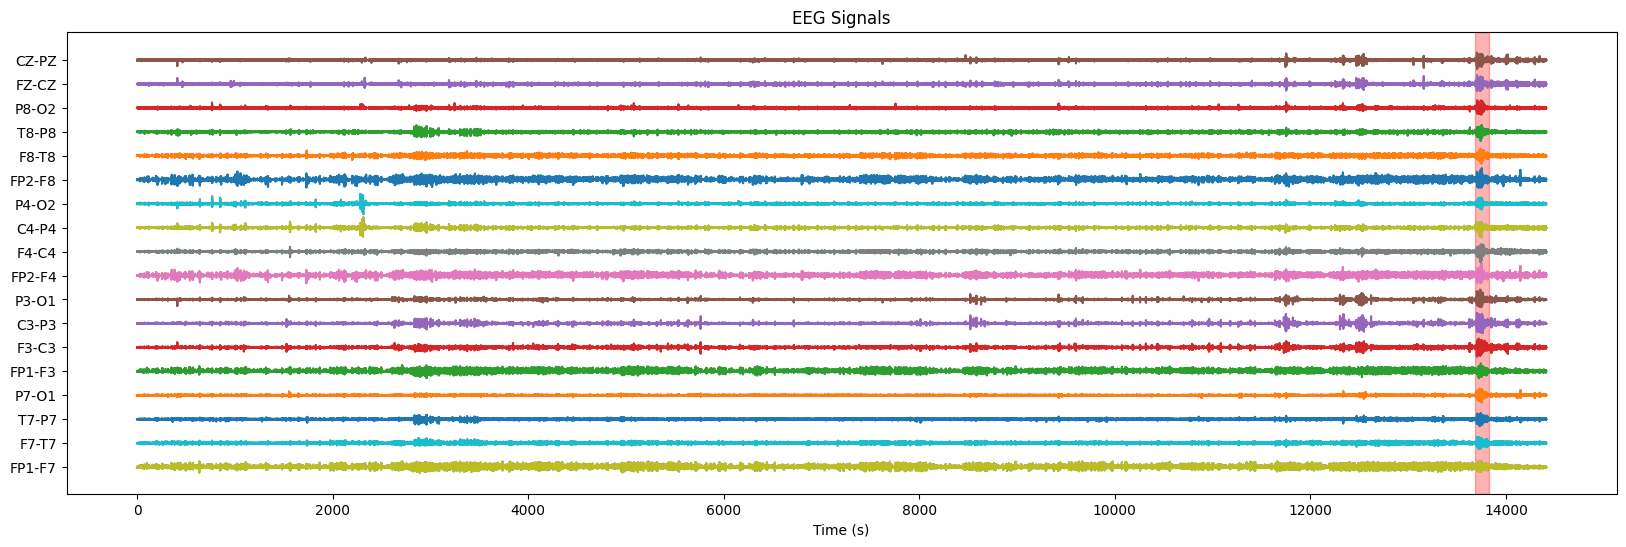

In [7]:
plt.figure(figsize=(20, 6))

n_channels = signals.shape[0]
t = np.arange(signals.shape[1]) / fs

offset = 0
spacing = np.max(np.abs(signals)) * 2

for i in range(n_channels):
    plt.plot(t, signals[i] + offset, label=ch_names[i])
    offset += spacing

# --- FIXED seizure highlighting ---
intervals = np.array(intervals)

if intervals.size > 0:
    if intervals.ndim == 1:
        intervals = intervals.reshape(1, -1)

    for start, end in intervals:
        plt.axvspan(start / fs, end / fs, color='red', alpha=0.3)

yticks = []
ylabels = []

offset = 0
for i in range(n_channels):
    plt.plot(t, signals[i] + offset)
    yticks.append(offset)
    ylabels.append(ch_names[i])
    offset += spacing

plt.xlabel("Time (s)")
plt.title("EEG Signals")
plt.yticks(yticks, ylabels)
plt.show()

# 3. Function for plotting

In [8]:

def plot_eeg(
    signals,
    fs,
    ch_names=None,
    intervals=None,
    channels=None,        # list of indices OR names
    t_start=None,         # in seconds
    t_end=None,           # in seconds
    figsize=(15, 8),
    color_mode=None,
    seizure_color= '#bfd630',
    seizure_alpha = 0.4,
    title = 'EEG Signals',
    linewidth=1
):
    """
    Flexible EEG plotter.

    Parameters:
    - signals: (n_channels, n_samples)
    - fs: sampling frequency
    - ch_names: list of channel names
    - intervals: seizure intervals (samples or seconds)
    - channels: list of channel indices OR names to plot
    - t_start, t_end: time window in seconds
    - figsize: figure size
    """

    # --- Channel selection ---
    if channels is not None:
        if isinstance(channels[0], str):
            idx = [ch_names.index(ch) for ch in channels]
        else:
            idx = channels
        signals = signals[idx]
        if ch_names is not None:
            ch_names = [ch_names[i] for i in idx]

    n_channels, n_samples = signals.shape

    # --- Time window selection ---
    if t_start is None:
        t_start = 0
    if t_end is None:
        t_end = n_samples / fs

    start_sample = int(t_start * fs)
    end_sample = int(t_end * fs)

    signals = signals[:, start_sample:end_sample]
    t = np.arange(start_sample, end_sample) / fs



    # Color
    # --- COLOR SETUP ---
    if color_mode == "tab10":
        colors = plt.cm.tab10(np.linspace(0, 1, n_channels))
    elif color_mode == "viridis":
        colors = plt.cm.viridis(np.linspace(0, 1, n_channels))
    else:
        colors = ["gray"] * n_channels

        
    # --- Plot ---
    plt.figure(figsize=figsize)

    spacing = np.max(np.abs(signals)) * 2
    offset = 0

    yticks = []
    ylabels = []

    for i in range(n_channels):
        plt.plot(t, signals[i] + offset, color=colors[i], linewidth=linewidth)
        yticks.append(offset)
        if ch_names is not None:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f"Ch {i}")
        offset += spacing
    
    plt.yticks(yticks, ylabels)


    # --- Seizure highlighting (FIXED) ---
    if intervals is not None:
        intervals = np.array(intervals)

        if intervals.size > 0:
            if intervals.ndim == 1:
                intervals = intervals.reshape(1, -1)

            for start, end in intervals:

                # --- ALWAYS convert to seconds ---
                start = start / fs
                end = end / fs

                # --- check overlap with window ---
                if end >= t_start and start <= t_end:

                    # --- clip to visible region ---
                    start_clip = max(start, t_start)
                    end_clip = min(end, t_end)

                    plt.axvspan(start_clip, end_clip, color=seizure_color, alpha=seizure_alpha)

    plt.xlabel("Time (s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 3.1 Change Figure Size

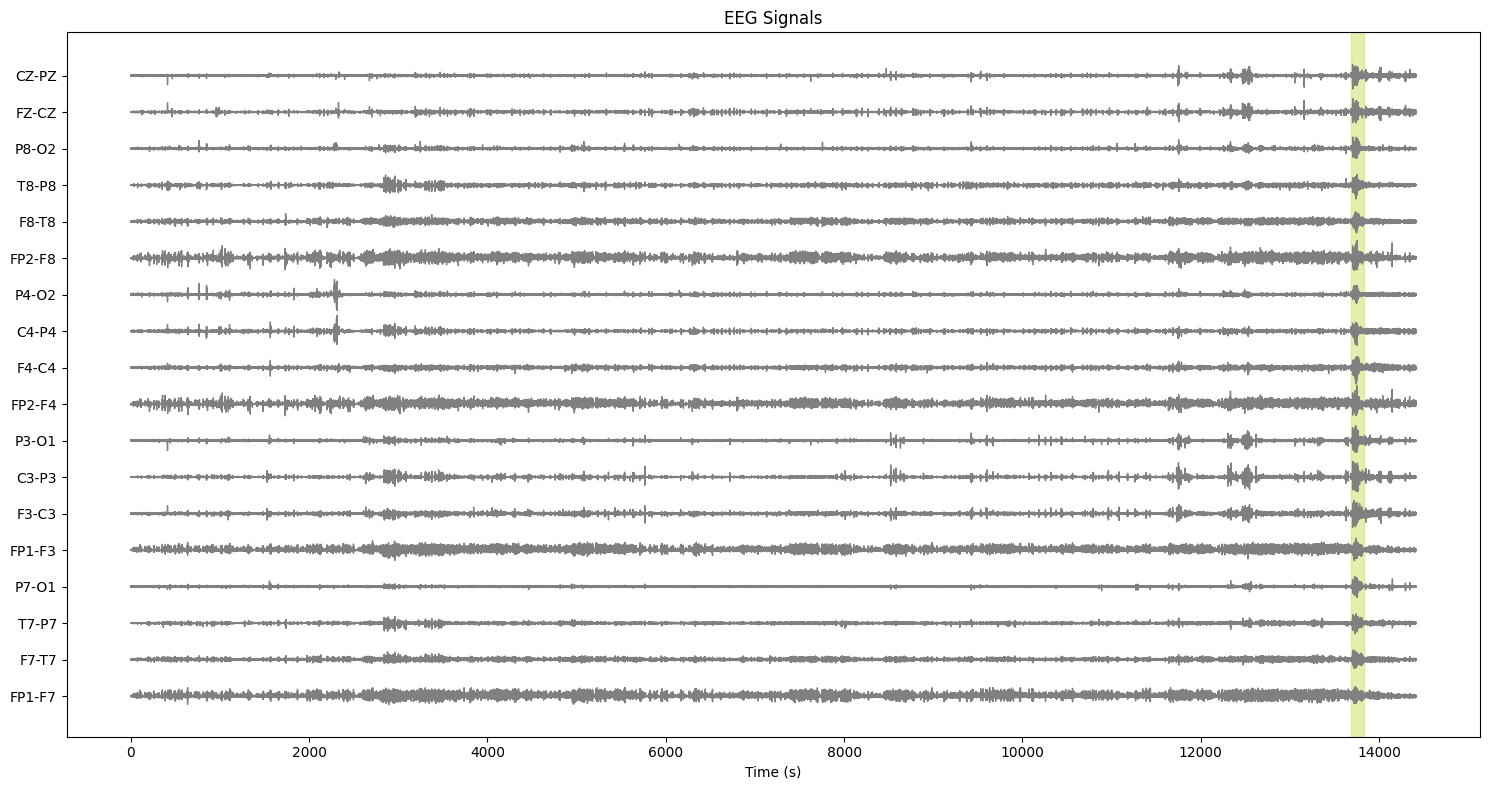

In [9]:
plot_eeg(signals, fs, ch_names, intervals=intervals,figsize=(15, 8),)

## 3.2 Plot Specific Channels

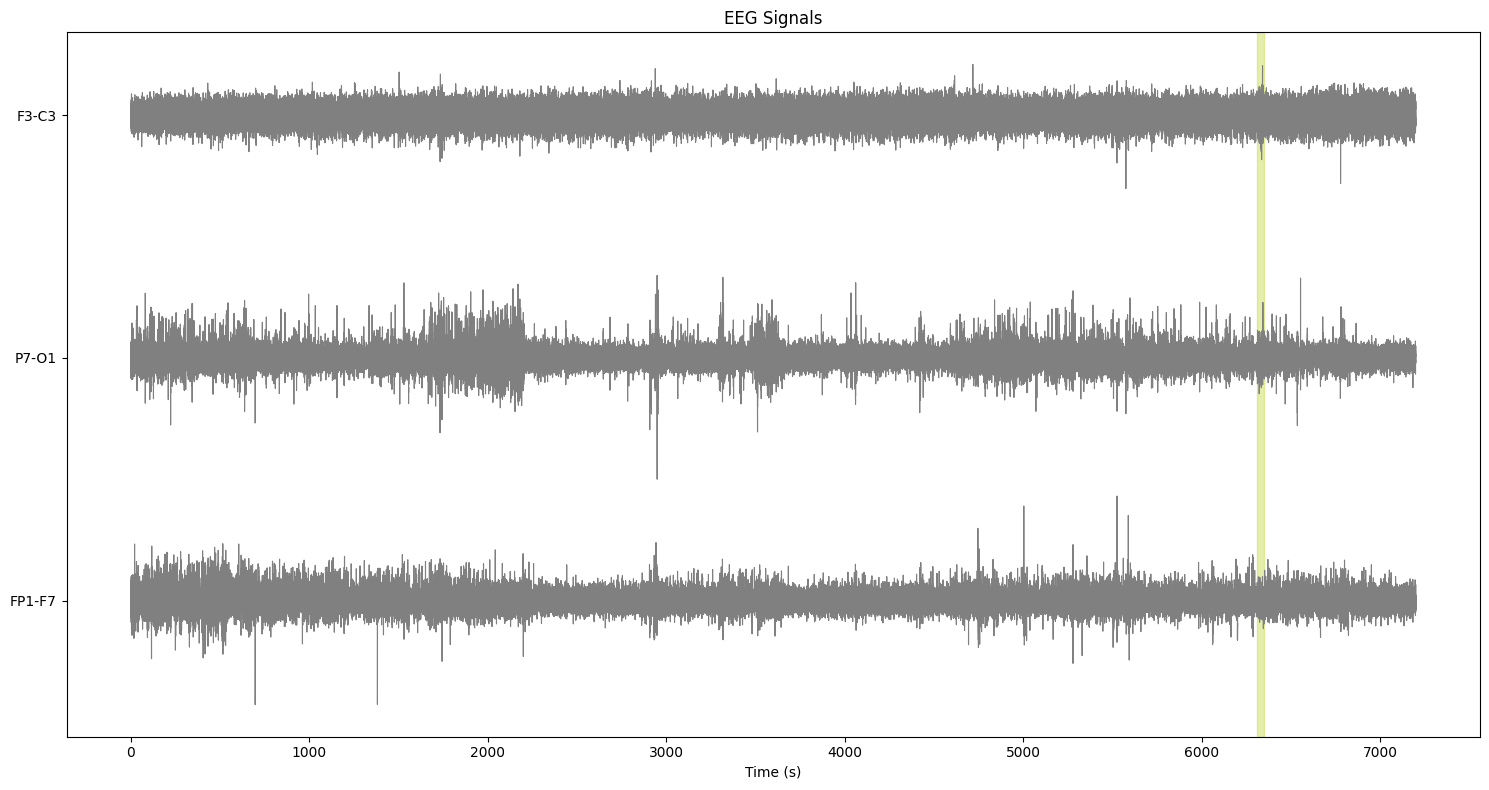

In [10]:
plot_eeg(signals, fs, ch_names, intervals, channels=[0, 3, 5], linewidth=0.8)

## 3.3 Plot Different Time Interval

## 3.4 Change Colors

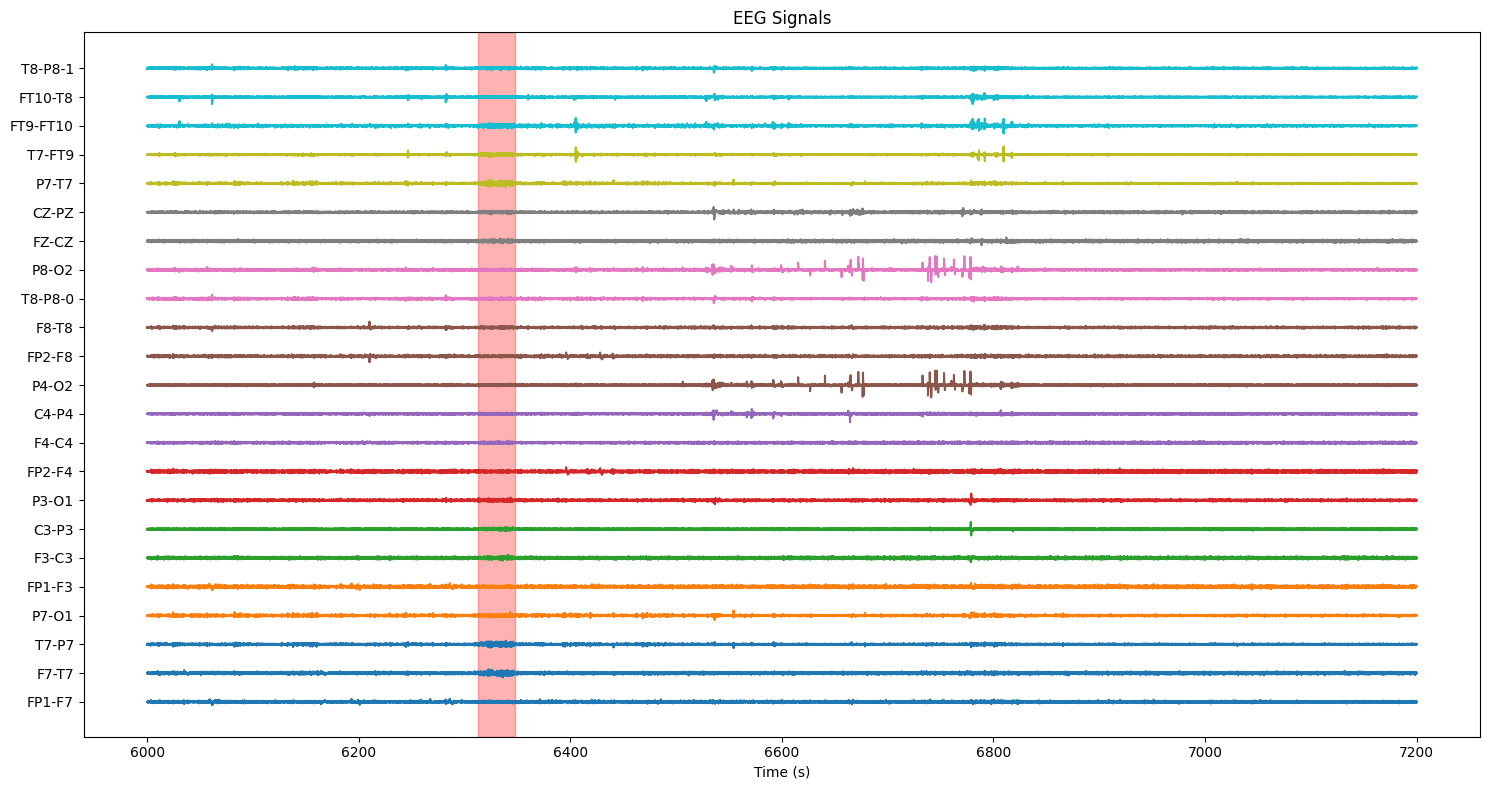

In [36]:
plot_eeg(signals, fs, ch_names, intervals=intervals,t_start= 6000, color_mode='tab10',seizure_color='red', seizure_alpha=0.3)

# 4. Plot Pwer Spectral Density

## 4.1 EDF File

C:\Users\ritaw\AppData\Local\Temp\ipykernel_12168\2048393055.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


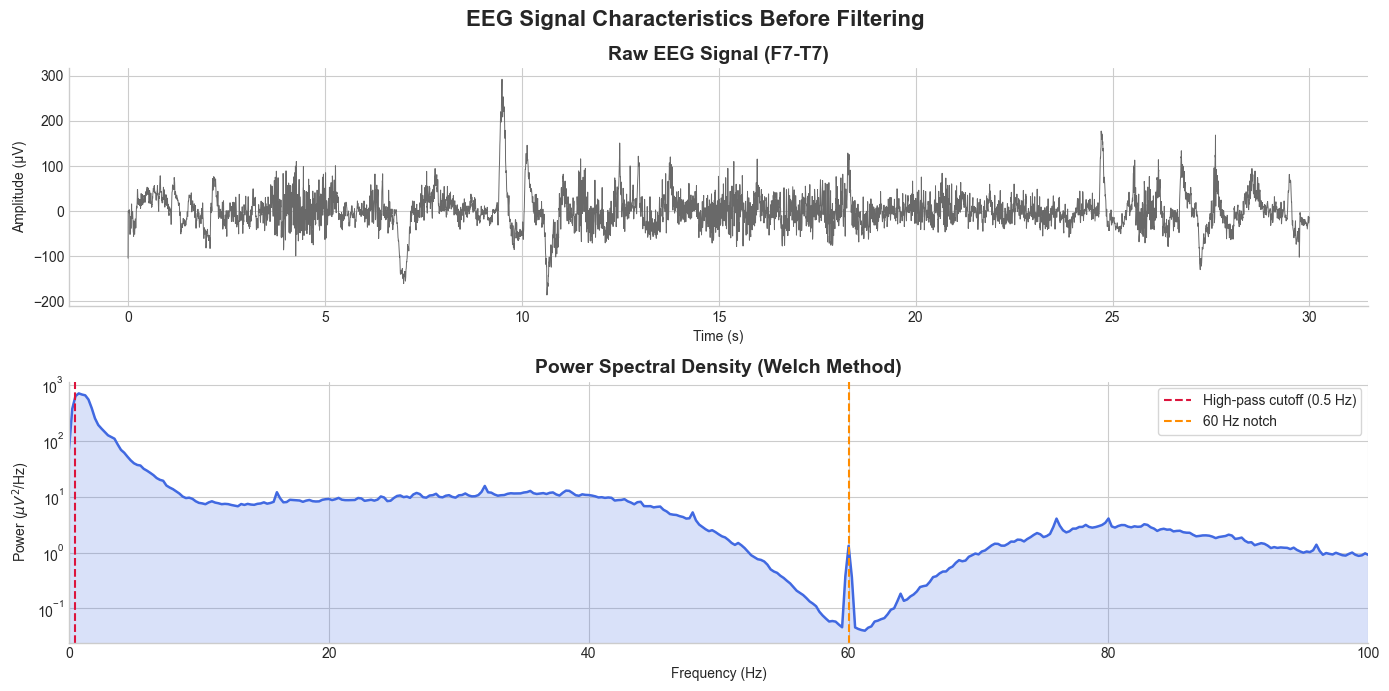

In [11]:
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# Load EDF
# -----------------------------
raw = mne.io.read_raw_edf(
    '../Dataset/chb01/chb01_01.edf',
    preload=True,
    verbose=False
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = 'F7-T7'
ch_idx = raw.ch_names.index(channel_name)

# MNE returns volts -> convert to µV
signal = raw.get_data()[ch_idx] * 1e6

fs = raw.info['sfreq']
t = np.arange(len(signal)) / fs

# -----------------------------
# Time window for visualization
# -----------------------------
window_sec = 30
n_samples = int(window_sec * fs)

t_window = t[:n_samples]
sig_window = signal[:n_samples]

# -----------------------------
# PSD using Welch
# -----------------------------
freqs, psd = welch(
    signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plotting
# -----------------------------
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    gridspec_kw={'height_ratios': [1, 1.1]}
)

# -----------------------------
# Time-domain EEG
# -----------------------------
axes[0].plot(
    t_window,
    sig_window,
    color='dimgray',
    linewidth=0.7
)

axes[0].set_title(
    f'Raw EEG Signal ({channel_name})',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')

# Cleaner appearance
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# -----------------------------
# PSD
# -----------------------------
axes[1].semilogy(
    freqs,
    psd,
    color='royalblue',
    linewidth=1.8
)

# Fill under curve
axes[1].fill_between(
    freqs,
    psd,
    alpha=0.2,
    color='royalblue'
)

# Mark filtering regions
axes[1].axvline(
    0.5,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='High-pass cutoff (0.5 Hz)'
)

axes[1].axvline(
    60,
    color='darkorange',
    linestyle='--',
    linewidth=1.5,
    label='60 Hz notch'
)

axes[1].set_xlim(0, 100)

axes[1].set_title(
    'Power Spectral Density (Welch Method)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'Power ($\mu V^2$/Hz)')

axes[1].legend(frameon=True)

# Cleaner appearance
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# -----------------------------
# Layout
# -----------------------------
fig.suptitle(
    'EEG Signal Characteristics Before Filtering',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# Load EDF
# -----------------------------
raw = mne.io.read_raw_edf(
    '../Dataset/chb01/chb01_01.edf',
    preload=True,
    verbose=False
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = 'F7-T7'
ch_idx = raw.ch_names.index(channel_name)

# MNE returns volts -> convert to µV
signal = raw.get_data()[ch_idx] * 1e6

fs = raw.info['sfreq']
t = np.arange(len(signal)) / fs

# -----------------------------
# Time window for visualization
# -----------------------------
window_sec = 30
n_samples = int(window_sec * fs)

t_window = t[:n_samples]
sig_window = signal[:n_samples]

# -----------------------------
# PSD using Welch
# -----------------------------
freqs, psd = welch(
    signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plotting
# -----------------------------
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    gridspec_kw={'height_ratios': [1, 1.1]}
)

# -----------------------------
# Time-domain EEG
# -----------------------------
axes[0].plot(
    t_window,
    sig_window,
    color='dimgray',
    linewidth=0.7
)

axes[0].set_title(
    f'Raw EEG Signal ({channel_name})',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')

# Cleaner appearance
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# -----------------------------
# PSD
# -----------------------------
axes[1].semilogy(
    freqs,
    psd,
    color='royalblue',
    linewidth=1.8
)

# Fill under curve
axes[1].fill_between(
    freqs,
    psd,
    alpha=0.2,
    color='royalblue'
)

# Mark filtering regions
axes[1].axvline(
    0.5,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='High-pass cutoff (0.5 Hz)'
)

axes[1].axvline(
    60,
    color='darkorange',
    linestyle='--',
    linewidth=1.5,
    label='60 Hz notch'
)

axes[1].set_xlim(0, 100)

axes[1].set_title(
    'Power Spectral Density (Welch Method)',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel(r'Power ($\mu V^2$/Hz)')

axes[1].legend(frameon=True)

# Cleaner appearance
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# -----------------------------
# Layout
# -----------------------------
fig.suptitle(
    'EEG Signal Characteristics Before Filtering',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

Extracting EDF parameters from c:\Users\ritaw\Desktop\Dataset\chb01\chb01_01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


C:\Users\ritaw\AppData\Local\Temp\ipykernel_19792\3176023217.py:4: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf('../Dataset/chb01/chb01_01.edf', preload=True)


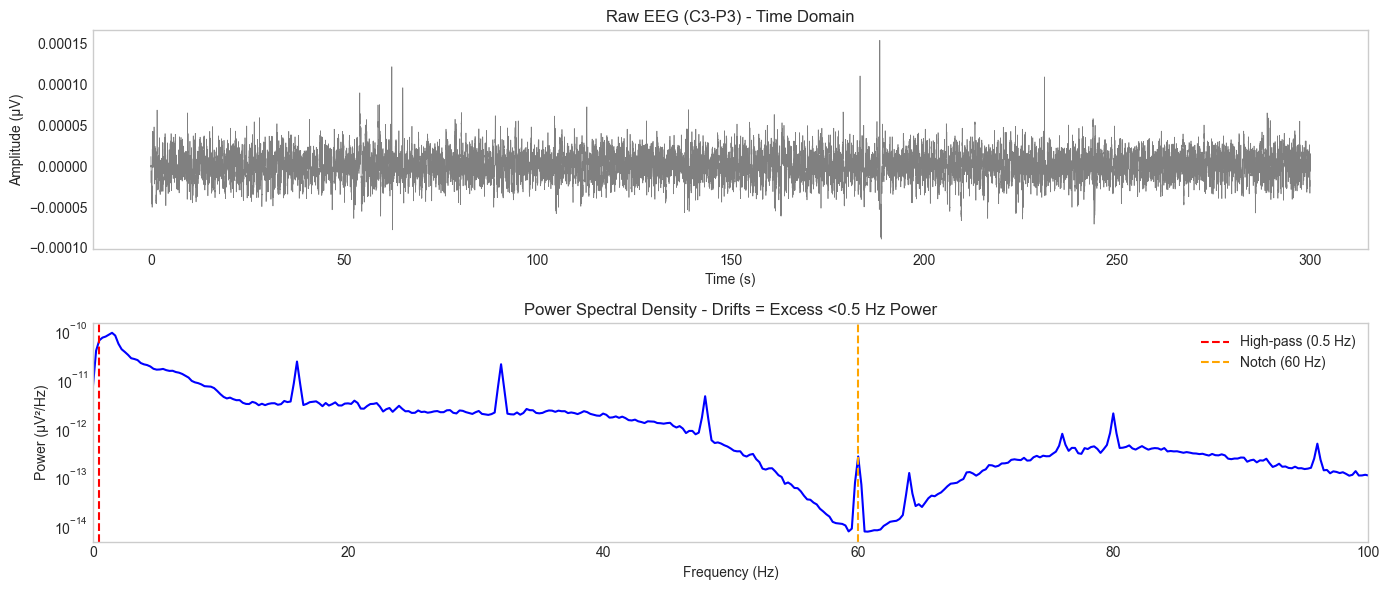

In [27]:
import mne
import matplotlib.pyplot as plt

raw = mne.io.read_raw_edf('../Dataset/chb01/chb01_01.edf', preload=True)

# Extract one channel (e.g., C3-P3 central)
ch_idx = raw.ch_names.index('C3-P3')
signal = raw.get_data()[ch_idx]
fs = raw.info['sfreq']
t = np.arange(len(signal)) / fs

# Plot side-by-side
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Time domain (first 300s)
t_window = t[:300*256]
sig_window = signal[:300*256]
axes[0].plot(t_window, sig_window, color='gray', linewidth=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title('Raw EEG (C3-P3) - Time Domain')
axes[0].grid()

# PSD (Power Spectral Density) - shows frequency content
from scipy.signal import welch
freqs, psd = welch(signal, fs, nperseg=256*4)
axes[1].semilogy(freqs, psd, color='blue', linewidth=1.5)
axes[1].axvline(0.5, color='red', linestyle='--', label='High-pass (0.5 Hz)')
axes[1].axvline(60, color='orange', linestyle='--', label='Notch (60 Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power (µV²/Hz)')
axes[1].set_title('Power Spectral Density - Drifts = Excess <0.5 Hz Power')
axes[1].set_xlim([0, 100])
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

C:\Users\ritaw\AppData\Local\Temp\ipykernel_12168\219744225.py:26: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


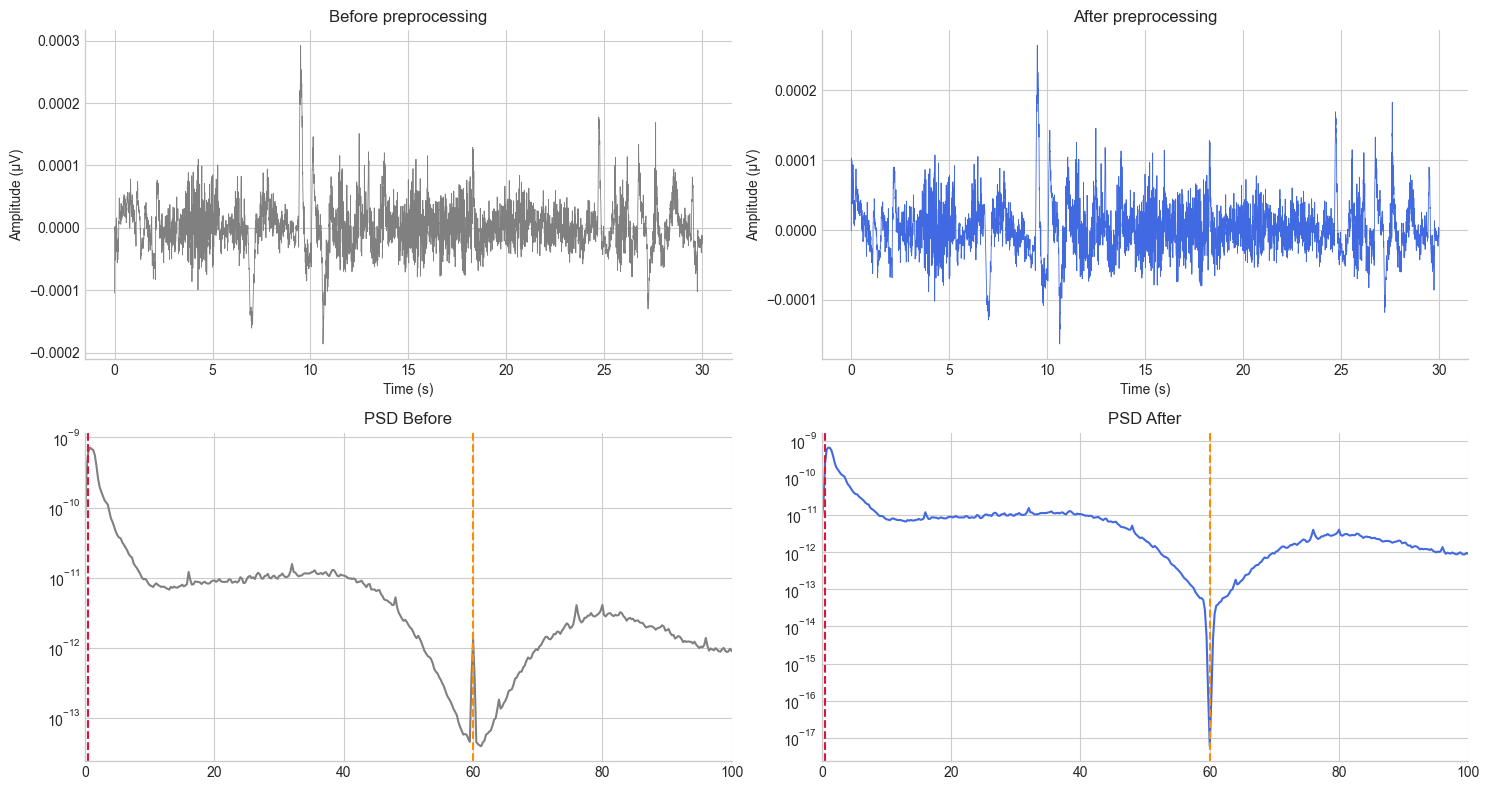

In [14]:
import numpy as np
import h5py
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# ----------------------------------------------------
# HDF5 loader
# ----------------------------------------------------
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names

# ----------------------------------------------------
# BEFORE (EDF)
# ----------------------------------------------------
raw = mne.io.read_raw_edf(
    "../Dataset/chb01/chb01_01.edf",
    preload=True,
    verbose=False
)

channel = "F7-T7"

idx_edf = raw.ch_names.index(channel)
signal_before = raw.get_data()[idx_edf]
fs_before = raw.info["sfreq"]

# ----------------------------------------------------
# AFTER (HDF5)
# ----------------------------------------------------
signals, fs_after, ch_names = load_h5("../Data/chb01_01.h5")

idx_h5 = ch_names.index(channel)
signal_after = signals[idx_h5]

# ----------------------------------------------------
# Time vectors
# ----------------------------------------------------
window_sec = 30

n_before = int(window_sec * fs_before)
n_after = int(window_sec * fs_after)

t_before = np.arange(n_before) / fs_before
t_after = np.arange(n_after) / fs_after

# ----------------------------------------------------
# PSD
# ----------------------------------------------------
freq_before, psd_before = welch(
    signal_before,
    fs_before,
    nperseg=int(fs_before * 4)
)

freq_after, psd_after = welch(
    signal_after,
    fs_after,
    nperseg=int(fs_after * 4)
)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# ---------------- Time ----------------
axes[0,0].plot(
    t_before,
    signal_before[:n_before],
    color="gray",
    lw=0.6
)
axes[0,0].set_title("Before preprocessing")
axes[0,0].set_xlabel("Time (s)")
axes[0,0].set_ylabel("Amplitude (µV)")

axes[0,1].plot(
    t_after,
    signal_after[:n_after],
    color="royalblue",
    lw=0.6
)
axes[0,1].set_title("After preprocessing")
axes[0,1].set_xlabel("Time (s)")
axes[0,1].set_ylabel("Amplitude (µV)")

# ---------------- PSD ----------------
axes[1,0].semilogy(freq_before, psd_before, color="gray")
axes[1,0].axvline(0.5, color="crimson", ls="--")
axes[1,0].axvline(60, color="darkorange", ls="--")
axes[1,0].set_xlim(0,100)
axes[1,0].set_title("PSD Before")

axes[1,1].semilogy(freq_after, psd_after, color="royalblue")
axes[1,1].axvline(0.5, color="crimson", ls="--")
axes[1,1].axvline(60, color="darkorange", ls="--")
axes[1,1].set_xlim(0,100)
axes[1,1].set_title("PSD After")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\ritaw\AppData\Local\Temp\ipykernel_12168\1456456487.py:26: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


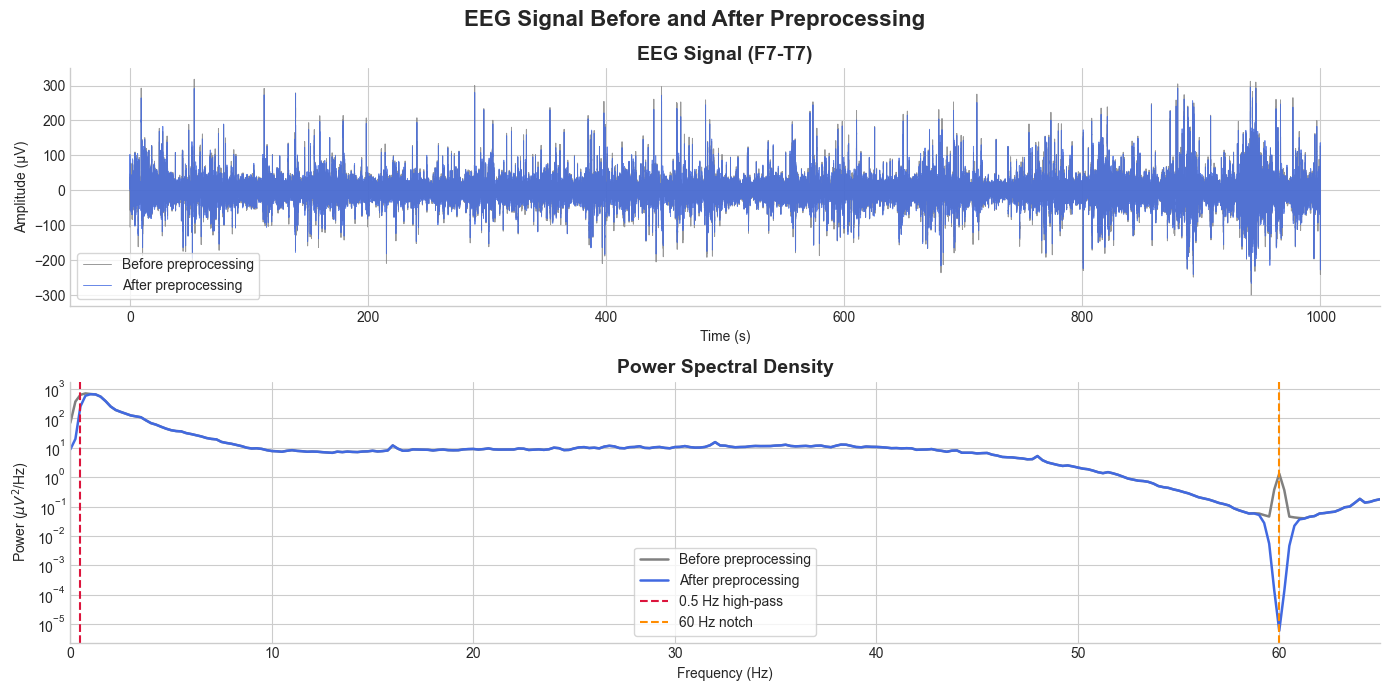

In [26]:
import numpy as np
import h5py
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

# ----------------------------------------------------
# HDF5 loader
# ----------------------------------------------------
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names

# ----------------------------------------------------
# Load original EDF
# ----------------------------------------------------
raw = mne.io.read_raw_edf(
    "../Dataset/chb01/chb01_01.edf",
    preload=True,
    verbose=False
)

channel = "F7-T7"

idx = raw.ch_names.index(channel)
signal_before = raw.get_data()[idx]
fs_before = raw.info["sfreq"]

# ----------------------------------------------------
# Load processed HDF5
# ----------------------------------------------------
signals, fs_after, ch_names = load_h5("../Data/chb01_01.h5")

idx = ch_names.index(channel)
signal_after = signals[idx]

# ----------------------------------------------------
# Convert V → µV
# ----------------------------------------------------
signal_before *= 1e6
signal_after *= 1e6

# ----------------------------------------------------
# Time window (10 s)
# ----------------------------------------------------
window_sec = 1000
n = int(window_sec * fs_before)

t = np.arange(n) / fs_before

# ----------------------------------------------------
# PSD (computed AFTER conversion to µV)
# ----------------------------------------------------
freq_before, psd_before = welch(
    signal_before,
    fs=fs_before,
    nperseg=int(fs_before * 4)
)

freq_after, psd_after = welch(
    signal_after,
    fs=fs_after,
    nperseg=int(fs_after * 4)
)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    gridspec_kw={"height_ratios": [1, 1.1]}
)

# ---------------- Time ----------------
axes[0].plot(
    t,
    signal_before[:n],
    color="gray",
    lw=0.7,
    alpha=0.8,
    label="Before preprocessing"
)

axes[0].plot(
    t,
    signal_after[:n],
    color="royalblue",
    lw=0.7,
    alpha=0.8,
    label="After preprocessing"
)

axes[0].set_title(f"EEG Signal ({channel})", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (µV)")
axes[0].legend(frameon=True)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ---------------- PSD ----------------
axes[1].semilogy(
    freq_before,
    psd_before,
    color="gray",
    lw=1.8,
    label="Before preprocessing"
)

axes[1].semilogy(
    freq_after,
    psd_after,
    color="royalblue",
    lw=1.8,
    label="After preprocessing"
)

axes[1].axvline(
    0.5,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="0.5 Hz high-pass"
)

axes[1].axvline(
    60,
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label="60 Hz notch"
)

axes[1].set_xlim(0, 65)
axes[1].set_title("Power Spectral Density", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"Power ($\mu V^2$/Hz)")
axes[1].legend(frameon=True)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    "EEG Signal Before and After Preprocessing",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

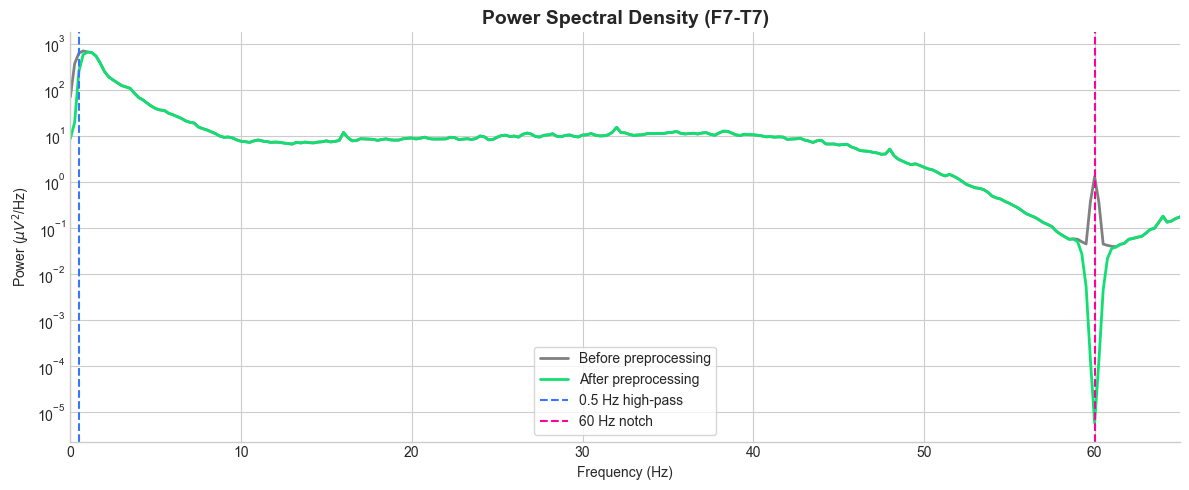

In [31]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(12, 5))

plt.semilogy(
    freq_before,
    psd_before,
    color="gray",
    lw=2,
    label="Before preprocessing"
)

plt.semilogy(
    freq_after,
    psd_after,
    color="#0fe071",
    lw=2,
    label="After preprocessing"
)

plt.axvline(
    0.5,
    color="#3777ff",
    linestyle="--",
    linewidth=1.5,
    label="0.5 Hz high-pass"
)

plt.axvline(
    60,
    color="#ff009c",
    linestyle="--",
    linewidth=1.5,
    label="60 Hz notch"
)

plt.xlim(0, 65)

plt.title(
    f"Power Spectral Density ({channel})",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Power ($\mu V^2$/Hz)")

plt.legend(frameon=True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 4.2 HDF5 File

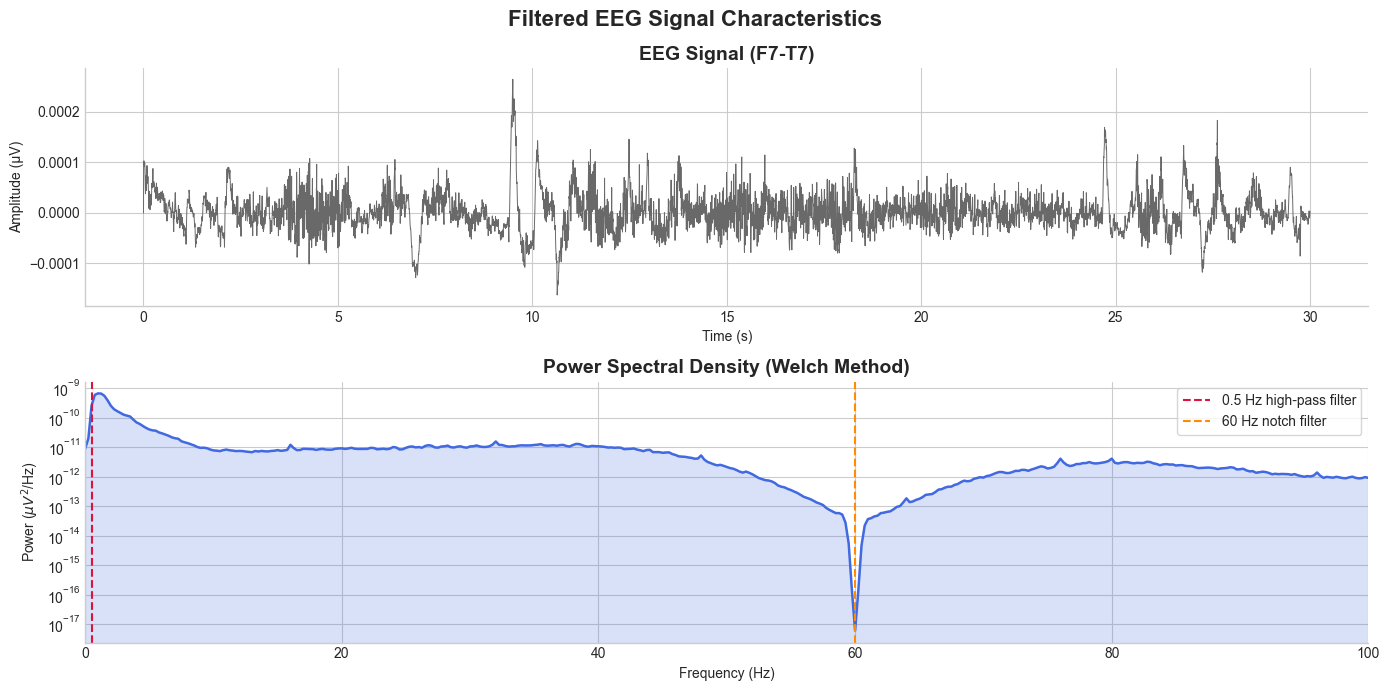

In [13]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------
# HDF5 loader
# -----------------------------
def load_h5(path):

    with h5py.File(path, "r") as f:

        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]

        intervals = (
            f["seizure_intervals"][:]
            if "seizure_intervals" in f
            else np.array([])
        )

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names, intervals

# -----------------------------
# Load file
# -----------------------------
signals, fs, ch_names, intervals = load_h5(
    "../Data/chb01_01.h5"
)

# -----------------------------
# Select channel
# -----------------------------
channel_name = "F7-T7"
ch_idx = ch_names.index(channel_name)

signal = signals[ch_idx]

# -----------------------------
# Time vector
# -----------------------------
t = np.arange(len(signal)) / fs

# -----------------------------
# 30-second window
# -----------------------------
window_sec = 30
n_samples = int(window_sec * fs)

t_window = t[:n_samples]
sig_window = signal[:n_samples]

# -----------------------------
# PSD
# -----------------------------
freqs, psd = welch(
    signal,
    fs=fs,
    nperseg=int(fs * 4)
)

# -----------------------------
# Plotting
# -----------------------------
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 7),
    gridspec_kw={"height_ratios": [1, 1.1]}
)

# -----------------------------
# EEG signal
# -----------------------------
axes[0].plot(
    t_window,
    sig_window,
    color="dimgray",
    linewidth=0.7
)

axes[0].set_title(
    f"EEG Signal ({channel_name})",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (µV)")

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# -----------------------------
# PSD
# -----------------------------
axes[1].semilogy(
    freqs,
    psd,
    color="royalblue",
    linewidth=1.8
)

axes[1].fill_between(
    freqs,
    psd,
    alpha=0.2,
    color="royalblue"
)

axes[1].axvline(
    0.5,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="0.5 Hz high-pass filter"
)

axes[1].axvline(
    60,
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label="60 Hz notch filter"
)

axes[1].set_xlim(0, 100)

axes[1].set_title(
    "Power Spectral Density (Welch Method)",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"Power ($\mu V^2$/Hz)")

axes[1].legend(frameon=True)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle(
    "Filtered EEG Signal Characteristics",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

# 5. Check existing files

## 5.1 Check for existing Seizure Files

In [5]:
from pathlib import Path

# paths
records_file = "RECORDS-WITH-SEIZURES-H5.txt"
features_dir = Path("Features/Seizure/")

# read seizure records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_seizure.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

print("\nSummary")
print(f"Total records : {len(records)}")
print(f"Found         : {len(records) - len(missing)}")
print(f"Missing       : {len(missing)}")

if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

Checking feature files...

FOUND   : chb01_03_seizure.mat
FOUND   : chb01_04_seizure.mat
FOUND   : chb01_15_seizure.mat
FOUND   : chb01_16_seizure.mat
FOUND   : chb01_18_seizure.mat
FOUND   : chb01_21_seizure.mat
FOUND   : chb01_26_seizure.mat
FOUND   : chb02_16+_seizure.mat
FOUND   : chb02_16_seizure.mat
FOUND   : chb02_19_seizure.mat
FOUND   : chb03_01_seizure.mat
FOUND   : chb03_02_seizure.mat
FOUND   : chb03_03_seizure.mat
FOUND   : chb03_04_seizure.mat
FOUND   : chb03_34_seizure.mat
FOUND   : chb03_35_seizure.mat
FOUND   : chb03_36_seizure.mat
FOUND   : chb04_05_seizure.mat
FOUND   : chb04_08_seizure.mat
FOUND   : chb04_28_seizure.mat
FOUND   : chb05_06_seizure.mat
FOUND   : chb05_13_seizure.mat
FOUND   : chb05_16_seizure.mat
FOUND   : chb05_17_seizure.mat
FOUND   : chb05_22_seizure.mat
FOUND   : chb06_01_seizure.mat
FOUND   : chb06_04_seizure.mat
FOUND   : chb06_09_seizure.mat
FOUND   : chb06_10_seizure.mat
FOUND   : chb06_13_seizure.mat
FOUND   : chb06_18_seizure.mat
FOUND   : c

In [3]:
# Read files
with open("RECORDS-H5.txt", "r") as f:
    all_records = {line.strip() for line in f if line.strip()}

with open("RECORDS-WITH-SEIZURES-H5.txt", "r") as f:
    seizure_records = {line.strip() for line in f if line.strip()}

# Records without seizures
non_seizure_records = sorted(all_records - seizure_records)

# Save to file
with open("RECORDS-WITHOUT-SEIZURES-H5.txt", "w") as f:
    for record in non_seizure_records:
        f.write(record + "\n")

print(f"Saved {len(non_seizure_records)} records to RECORDS-WITHOUT-SEIZURES-H5.txt")

FileNotFoundError: [Errno 2] No such file or directory: 'RECORDS-H5.txt'

## 5.2 Check for existing Non-seizure Files

In [6]:
from pathlib import Path

# paths
records_file = "RECORDS-WITHOUT-SEIZURES-H5.txt"
features_dir = Path("Features/Non_Seizure/")

# read seizure records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_features.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

print("\nSummary")
print(f"Total records : {len(records)}")
print(f"Found         : {len(records) - len(missing)}")
print(f"Missing       : {len(missing)}")

if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

Checking feature files...

FOUND   : chb01_01_features.mat
FOUND   : chb01_02_features.mat
FOUND   : chb01_05_features.mat
FOUND   : chb01_06_features.mat
FOUND   : chb01_07_features.mat
FOUND   : chb01_08_features.mat
FOUND   : chb01_09_features.mat
FOUND   : chb01_10_features.mat
FOUND   : chb01_11_features.mat
FOUND   : chb01_12_features.mat
FOUND   : chb01_13_features.mat
FOUND   : chb01_14_features.mat
FOUND   : chb01_17_features.mat
FOUND   : chb01_19_features.mat
FOUND   : chb01_20_features.mat
FOUND   : chb01_22_features.mat
FOUND   : chb01_23_features.mat
FOUND   : chb01_24_features.mat
FOUND   : chb01_25_features.mat
FOUND   : chb01_27_features.mat
FOUND   : chb01_29_features.mat
FOUND   : chb01_30_features.mat
FOUND   : chb01_31_features.mat
FOUND   : chb01_32_features.mat
FOUND   : chb01_33_features.mat
FOUND   : chb01_34_features.mat
FOUND   : chb01_36_features.mat
FOUND   : chb01_37_features.mat
FOUND   : chb01_38_features.mat
FOUND   : chb01_39_features.mat
FOUND   : chb

In [ ]:
from pathlib import Path

# paths
records_file = "RECORDS-WITHOUT-SEIZURES-H5.txt"
features_dir = Path("Features/Non_Seizure/")

# expected records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

expected_files = {f"{rec}_features.mat" for rec in records}

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_features.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

# actual files in folder
actual_files = {
    f.name for f in features_dir.glob("*_features.mat")
}

# extras
extra_files = actual_files - expected_files

print("\nSummary")
print(f"Expected records : {len(records)}")
print(f"Found            : {len(records) - len(missing)}")
print(f"Missing          : {len(missing)}")

print(f"\nFiles in folder  : {len(actual_files)}")
print(f"Extra files      : {len(extra_files)}")


if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

if extra_files:
    print("\nExtra feature files:")
    for f in sorted(extra_files):
        print(f)

# 6. Get Annotations

In [ ]:
from pathlib import Path

In [11]:
# Seizure files
feature_dir = Path("../Data")

files = sorted(feature_dir.glob("chb01_*.h5"))

print(len(files))
for f in files:
    print(f.name)

42
chb01_01.h5
chb01_02.h5
chb01_03.h5
chb01_04.h5
chb01_05.h5
chb01_06.h5
chb01_07.h5
chb01_08.h5
chb01_09.h5
chb01_10.h5
chb01_11.h5
chb01_12.h5
chb01_13.h5
chb01_14.h5
chb01_15.h5
chb01_16.h5
chb01_17.h5
chb01_18.h5
chb01_19.h5
chb01_20.h5
chb01_21.h5
chb01_22.h5
chb01_23.h5
chb01_24.h5
chb01_25.h5
chb01_26.h5
chb01_27.h5
chb01_29.h5
chb01_30.h5
chb01_31.h5
chb01_32.h5
chb01_33.h5
chb01_34.h5
chb01_36.h5
chb01_37.h5
chb01_38.h5
chb01_39.h5
chb01_40.h5
chb01_41.h5
chb01_42.h5
chb01_43.h5
chb01_46.h5


In [18]:
from pathlib import Path
import numpy as np
import h5py

# =====================================================
# LOAD FUNCTION (your version, kept clean)
# =====================================================
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names, intervals


# =====================================================
# PATHS
# =====================================================
feature_dir = Path("../Data")
records_file = "RECORDS-WITH-SEIZURES-H5.txt"

# =====================================================
# READ FILE LIST
# =====================================================
with open(records_file, "r") as f:
    files = [line.strip() for line in f if line.strip()]

paths = [feature_dir / f for f in files]

print(f"Total files: {len(paths)}\n")


# =====================================================
# LOOP THROUGH FILES
# =====================================================
summary = []

for path in paths:
    signals, fs, ch_names, intervals = load_h5(path)

    print("=" * 60)
    print("File:", path.name)
    print("Signals shape:", signals.shape)
    print("Sampling rate:", fs)
    print("Channels:", len(ch_names))

    # -------------------------
    # seizure intervals handling
    # -------------------------
    if intervals.size == 0:
        print("Seizure intervals: NONE")
        n_seizures = 0
    else:
        print("Seizure intervals:")
        for i, (start, end) in enumerate(intervals):
            duration = end - start
            print(f"  Seizure {i+1}: {start:.1f}s → {end:.1f}s ({duration:.1f}s)")
        n_seizures = len(intervals)

    summary.append({
        "file": path.name,
        "n_seizures": n_seizures,
        "n_channels": len(ch_names),
        "n_samples": signals.shape[1] if signals.ndim > 1 else signals.shape[0],
        "fs": fs
    })


# =====================================================
# FINAL SUMMARY
# =====================================================
print("\n\n================ SUMMARY ================\n")

for s in summary:
    print(f"{s['file']}: seizures={s['n_seizures']}, "
          f"channels={s['n_channels']}, fs={s['fs']}")

Total files: 138

File: chb01_03.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 766976.0s → 777216.0s (10240.0s)
File: chb01_04.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 375552.0s → 382464.0s (6912.0s)
File: chb01_15.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 443392.0s → 453632.0s (10240.0s)
File: chb01_16.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 259840.0s → 272896.0s (13056.0s)
File: chb01_18.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 440320.0s → 463360.0s (23040.0s)
File: chb01_21.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 83712.0s → 107520.0s (23808.0s)
File: chb01_26.h5
Signals shape: (18, 595200)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 47

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py

feature_dir = Path("../Data")
records_file = "RECORDS-WITH-SEIZURES-H5.txt"


def load_h5(path):
    with h5py.File(path, "r") as f:
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        fs = f["sampling_rate"][()]
    return intervals, fs


with open(records_file, "r") as f:
    files = [line.strip() for line in f if line.strip()]

rows = []

for fname in files:
    path = feature_dir / fname
    intervals, fs = load_h5(path)

    if intervals.size == 0:
        continue

    file_id = fname.replace(".h5", "")   # ✅ remove extension

    for i, (start, end) in enumerate(intervals):
        rows.append({
            "file": file_id,
            "seizure_id": i + 1,

            # RAW (for ML)
            "start_sample": int(start),
            "end_sample": int(end),

            # CONVERTED (for interpretation)
            "start_sec": float(start / fs),
            "end_sec": float(end / fs),
            "duration_sec": float((end - start) / fs),
        })


df = pd.DataFrame(rows)
df.to_csv("seizure_annotations_full.csv", index=False)

print("Saved: seizure_annotations_full.csv")
print(df.head())

Saved: seizure_annotations_full.csv
       file  seizure_id  start_sample  end_sample  start_sec  end_sec  \
0  chb01_03           1        766976      777216     2996.0   3036.0   
1  chb01_04           1        375552      382464     1467.0   1494.0   
2  chb01_15           1        443392      453632     1732.0   1772.0   
3  chb01_16           1        259840      272896     1015.0   1066.0   
4  chb01_18           1        440320      463360     1720.0   1810.0   

   duration_sec  
0          40.0  
1          27.0  
2          40.0  
3          51.0  
4          90.0  
